In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "5"  # Limit OpenMP
os.environ["MKL_NUM_THREADS"] = "5"  # Limit MKL (Intel Math Kernel Library)
os.environ["OPENBLAS_NUM_THREADS"] = "5"  # Limit OpenBLAS
os.environ["NUMEXPR_MAX_THREADS"] = "5"  # Limit NumExpr if installed

In [3]:
import itertools
import json
from pathlib import Path
import re
from typing import Literal

from matplotlib.colors import CenteredNorm
from matplotlib import transforms
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import pickle
from scipy import stats
from scipy.stats import ttest_ind, pearsonr, spearmanr
import seaborn as sns
import textgrid
import torch
from tqdm.auto import tqdm, trange
tqdm.pandas()

from src.data import get_electrode_df, add_metadata_features
from src.models.causal4 import run_causal4_analysis
from src.models import causal4
import src.viz as viz

In [4]:
sns.set_context("talk", font_scale=1.4)

In [5]:
epochs_path = "outputs/epochs_preprocessed"
tg_dir = "textgrids"

include_rois = ["superiortemporal", "postcentral", "precentral", "supramarginal", "inferiortemporal", "middletemporal",
                "parsopercularis", "caudalmiddlefrontol", "lateralorbitofrontal", "temporalpole", "inferiorparietal",
                "rostralmiddlefrontal", "parstriangularis"]

# uncorrected p-value threshold
alpha = 0.01

# ERP sources from TIMIT data
timit_epoch_sources = {
    "All": "/userdata/jgauthier/projects/ideal-word-representations/phoneme_epochs-all.h5",
    "Word onset": "/userdata/jgauthier/projects/ideal-word-representations/phoneme_epochs-onsets.h5",
}

outdir = "outputs/causal4_searchlight"

In [6]:
all_epoch_paths = list(Path(epochs_path).glob("*.fif"))

In [7]:
epochs = {}
for path in tqdm(all_epoch_paths):
    subject_name = re.findall("(EC[\d]+)_epo", str(path))[0]
    epochs[subject_name] = mne.read_epochs(str(path))
    epochs[subject_name].metadata = add_metadata_features(epochs[subject_name].metadata)

  0%|          | 0/10 [00:00<?, ?it/s]

Reading /userdata/jgauthier/projects/barakeet/outputs/epochs_preprocessed/EC278_epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -400.00 ...    2990.00 ms
        0 CTF compensation matrices available
Adding metadata with 72 columns
1152 matching events found
No baseline correction applied
0 projection items activated
Replacing existing metadata with 100 columns
Reading /userdata/jgauthier/projects/barakeet/outputs/epochs_preprocessed/EC270_epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -400.00 ...    2990.00 ms
        0 CTF compensation matrices available
Adding metadata with 72 columns
432 matching events found
No baseline correction applied
0 projection items activated
Replacing existing metadata with 100 columns
Reading /userdata/jgauthier/projects/barakeet/outputs/epochs_preprocessed/EC253_epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -400.00 ...    2990.00 ms
        0 CTF compensation matri

In [10]:
# pre-compute bounds for TIMIT plots
timit_bounds = viz.precompute_timit_bounds(timit_epoch_sources, subjects=epochs.keys())

  0%|          | 0/10 [00:00<?, ?it/s]

EC279 not found in /userdata/jgauthier/projects/ideal-word-representations/phoneme_epochs-all.h5
EC279 not found in /userdata/jgauthier/projects/ideal-word-representations/phoneme_epochs-onsets.h5


In [8]:
electrode_df = pd.concat([get_electrode_df(subject_name) for subject_name in epochs.keys()],
                         keys=epochs.keys(), names=["subject"])
electrode_df["roi"] = electrode_df.roi.astype(str)
electrode_df = electrode_df.droplevel("electrode_name")

# Drop electrodes metadata which don't have corresponding data
for subject, epochs_i in epochs.items():
    electrode_df.loc[subject, "keep"] = np.arange(len(electrode_df.loc[subject])) < len(epochs_i.info["ch_names"])
electrode_df = electrode_df[electrode_df["keep"]].drop(columns="keep")

electrode_df

long_name   type                         roi
subject electrode_idx                                                  
EC278   0                  Temporal1   grid              middletemporal
        1                  Temporal2   grid              middletemporal
        2                  Temporal3   grid              middletemporal
        3                  Temporal4   grid              middletemporal
        4                  Temporal5   grid              middletemporal
...                              ...    ...                         ...
EC282   217             Hippocampus6  depth  ctx_lh_S_collat_transv_ant
        218             Hippocampus7  depth  ctx_lh_S_collat_transv_ant
        219             Hippocampus8  depth  Left-Cerebral-White-Matter
        220             Hippocampus9  depth       ctx_lh_G_temporal_inf
        221            Hippocampus10  depth  Left-Cerebral-White-Matter

[2332 rows x 3 columns]

In [9]:
results = torch.load(f"{outdir}/searchlight_results.pth")
all_results_meta = results["all_results_meta"]
searchlight_results_df = results["searchlight_results_df"]
searchlight_electrode_activations = results["searchlight_electrode_activations"]
searchlight_decoder_outputs = results["searchlight_decoder_outputs"]
populations_dict = results["populations_dict"]

n_repeats = max(repeat for _, repeat in all_results_meta.keys()) + 1

/tmp/ipykernel_3787401/3253722731.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  results = torch.load(f"{outdir}/searchlight_results.pth")


In [ ]:
# cache z-score parameters for each subject and electrode
parameter_cache = {}

def plot_searchlight_response(row):
    subject = row.subject
    phoneme_pair = row.phoneme_pair
    population_A = row.population_A
    population_B = [row.electrode_idx]
    left = row.left_is_best
    population_B_window = (int(row.window_start_samp), int(row.window_end_samp))

    plot_key = (subject, phoneme_pair, population_A)
    plot_num_quantiles = 4
    plot_meta = all_results_meta[plot_key, 0]

    population_A_spec = populations_dict[(subject, phoneme_pair, population_A)]
    population_A_window = population_A_spec["window_a"]
    # convert to samples
    population_A_window = (
        plot_meta.epochs.time_as_index(population_A_window[0])[0],
        plot_meta.epochs.time_as_index(population_A_window[1])[0],
    )

    # sanity check: test trials are the same across repeats
    test_trial_indices = np.array([all_results_meta[(plot_key, repeat)].test_trial_metadata.index
                                    for repeat in range(n_repeats)]).T
    for i in range(1, test_trial_indices.shape[1]):
        np.testing.assert_array_equal(
            test_trial_indices[:, i],
            test_trial_indices[:, 0],
        )

    # merge estimated probabilities from repeats
    p_gt_phoneme = np.array([all_results_meta[(plot_key, repeat)].p_gt_phoneme
                            for repeat in range(n_repeats)]).T
    p_gt_phoneme_binned = pd.qcut(p_gt_phoneme.mean(1), plot_num_quantiles)

    plot_meta_df = plot_meta.test_trial_metadata.copy()
    plot_meta_df["p_gt_phoneme"] = p_gt_phoneme.mean(1)
    plot_meta_df["p_gt_phoneme_binned"] = p_gt_phoneme_binned
    plot_meta_df["p_gt_phoneme_bin_center"] = plot_meta_df.p_gt_phoneme_binned.apply(
        lambda x: x.mid
    ).astype(float).round(3)

    def get_textgrid_path(row):
        return Path(tg_dir) / (Path(row.wav_file).with_suffix(".TextGrid").name)
    plot_meta_df["textgrid_path"] = plot_meta_df.apply(get_textgrid_path, axis=1)
    plot_meta_df = plot_meta_df.rename_axis("epoch_idx").reset_index()

    # cross by electrodes
    plot_meta_df = pd.merge(plot_meta_df,
                 electrode_df.loc[plot_meta.subject].loc[population_B].reset_index(),
                 how="cross")

    ####

    g_scatter = causal4.plot_causal4_scatter(
        plot_meta, plot_meta_df, subject, population_B_window, height=6)

    ####

    # displot showing spearmanr results
    spearmanr_results = np.array(row.counterfactual_spearmanr_list)
    g_displot = sns.displot(
        spearmanr_results,
        kind="kde", fill=True, color="blue",
        height=4, aspect=3,
    )
    spearmanr_obs = row.corr_left if row.p_val_left < row.p_val_right else row.corr_right
    g_displot.ax.axvline(spearmanr_obs, color="red", linestyle="--", label="Observed", linewidth=2)
    g_displot.ax.set_xlabel("Spearman correlation")
    g_displot.ax.set_title(f"Permutation baseline results\n(z={row.counterfactual_test_z:.2f}, p={row.counterfactual_test_p:.2g})")

    ####

    g = causal4.plot_causal4_evoked(
        plot_meta, plot_meta_df, subject, population_A_window, population_B_window,
        height=6, hue="p_gt_phoneme_bin_center"
    )

    ####

    # # plot re-aligned to behavior
    # def plot_facet_evoked_align_behavior(data, color, **kwargs):
    #     electrode_idx = data.electrode_idx.iloc[0]
    #     epoch_idxs = data.epoch_idx

    #     word_end = data.word_end.iloc[0]
    #     tg_path = data.textgrid_path.iloc[0]
    #     tg = textgrid.TextGrid.fromFile(str(tg_path))

    #     ax = plt.gca()
    #     ax.set_xlabel("Time relative to behavior onset (sec)")
    #     ax.set_ylabel("HGA")
    #     ax.set_title(f"{subject} {electrode_idx + 1}, {word_end}")

    #     # plot epoched response at this electrode
    #     plot_epochs = plot_meta.epochs[epoch_idxs]
    #     plot_epochs = causal4.realign_epochs_by_behavior(plot_epochs)

    #     plot_epoch_data = plot_epochs.copy().pick(electrode_idx).get_data().squeeze(1)
    #     assert plot_epoch_data.ndim == 2  # n_trials * n_times

    #     plot_times = plot_epochs.times
    #     plot_epoch_data_mean = np.nanmean(plot_epoch_data, 0)
    #     plot_epoch_data_sem = np.nanstd(plot_epoch_data, 0) / np.sqrt((~np.isnan(plot_epoch_data)).sum(0))
    #     ax.plot(plot_times, plot_epoch_data_mean, color=color, alpha=0.5, **kwargs)
    #     ax.fill_between(plot_times, plot_epoch_data_mean - plot_epoch_data_sem,
    #                     plot_epoch_data_mean + plot_epoch_data_sem, color=color, alpha=0.2)
        
    #     ax.set_xlim(plot_epochs.times[0], plot_epochs.times[-1])

    #     return ax
    
    # g_evoked_by_behavior = sns.FacetGrid(
    #     plot_meta_df,
    #     row="electrode_idx",
    #     hue="p_gt_phoneme_bin_center", palette="plasma",
    #     col="lexical_evidence",
    #     aspect=3, height=3, sharey="row"
    # ).map_dataframe(plot_facet_evoked_align_behavior).add_legend()
    # g_evoked_by_behavior.fig.suptitle("Evoked responses by P(gt phoneme), aligned to behavior onset")
    # DEV disable, not using
    g_evoked_by_behavior = None

    ####

    g_evoked_resampled = causal4.plot_causal4_evoked(
        plot_meta, plot_meta_df, subject, population_A_window, population_B_window,
        height=6, hue="resampled"
    )

    ####

    g_raster, cax_f = causal4.plot_causal4_raster(
        plot_meta, plot_meta_df, subject, population_B_window,
        height=6,
        sort_by="p_gt_phoneme", parameter_cache=parameter_cache)
    
    g_raster_resampled, extra_cax = causal4.plot_causal4_raster(
        plot_meta, plot_meta_df, subject, population_B_window,
        height=6,
        sort_by="resampled", parameter_cache=parameter_cache)
    plt.close(extra_cax)
    
    # g_raster_behavior = causal4.plot_causal4_raster(
    #     plot_meta, plot_meta_df, subject, population_B_window,
    #     height=6,
    #     sort_by="behavior_linear", parameter_cache=parameter_cache)
    g_raster_behavior = None  # DEV disable, not using

    ####

    timit_fig = viz.timit_subplots(
        subject, population_B[0],
        plot_phonemes=[ph.upper() for ph in phoneme_pair],
        cell_height=6, cell_aspect=1.5,
        epoch_sources=timit_epoch_sources,
        timit_bounds_dict=timit_bounds)
    timit_fig.suptitle(f"TIMIT responses for {subject} {population_B[0] + 1}", y=1.1)

    return (g_scatter, g_displot,
            g, g_evoked_by_behavior, g_evoked_resampled,
            g_raster, cax_f, g_raster_resampled, g_raster_behavior,
            timit_fig)

long_name                                                              Temporal108
type                                                                          grid
roi                                                                  supramarginal
speech_responsive                                                             True
corr_left                                                                 0.379939
p_val_left                                                                0.007731
corr_right                                                               -0.494247
p_val_right                                                               0.000356
control_corr_left                                                         0.040352
control_p_val_left                                                        0.785383
control_corr_right                                                       -0.018831
control_p_val_right                                                       0.898911
elec

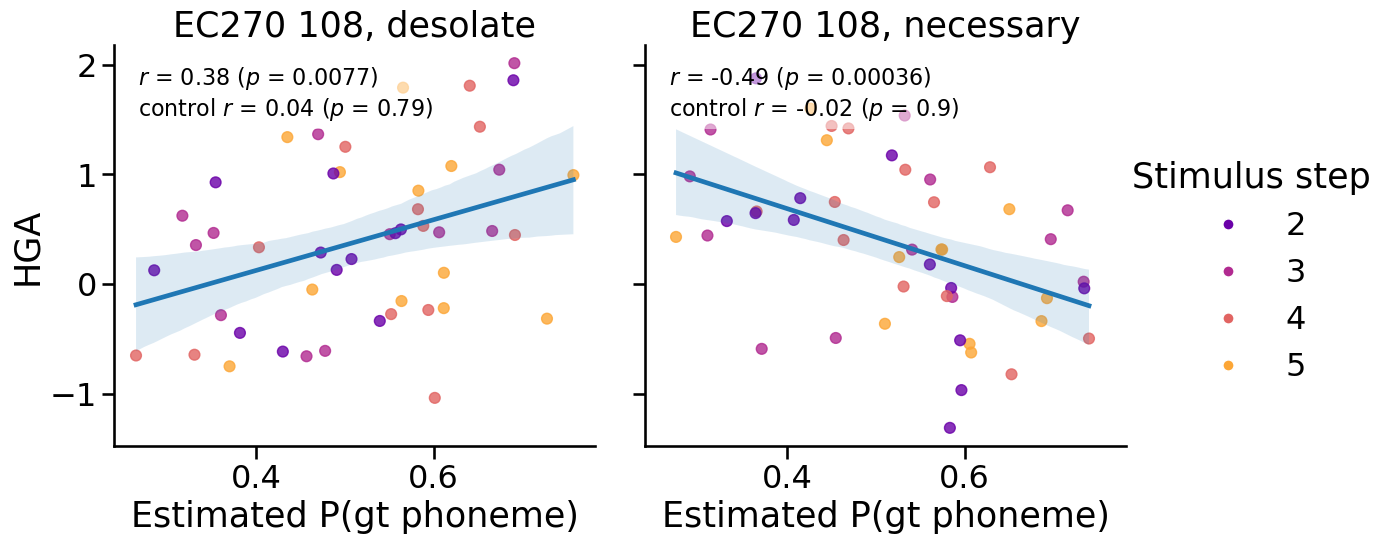

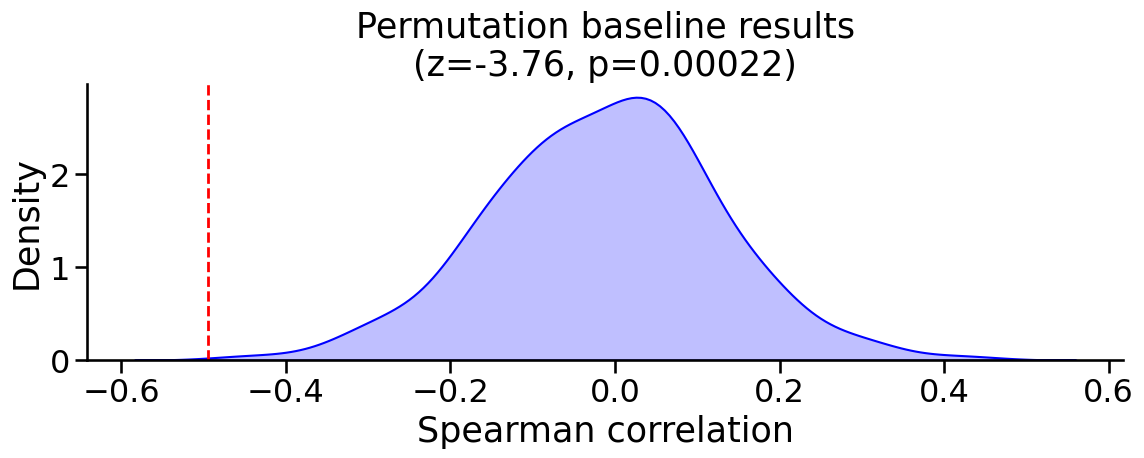

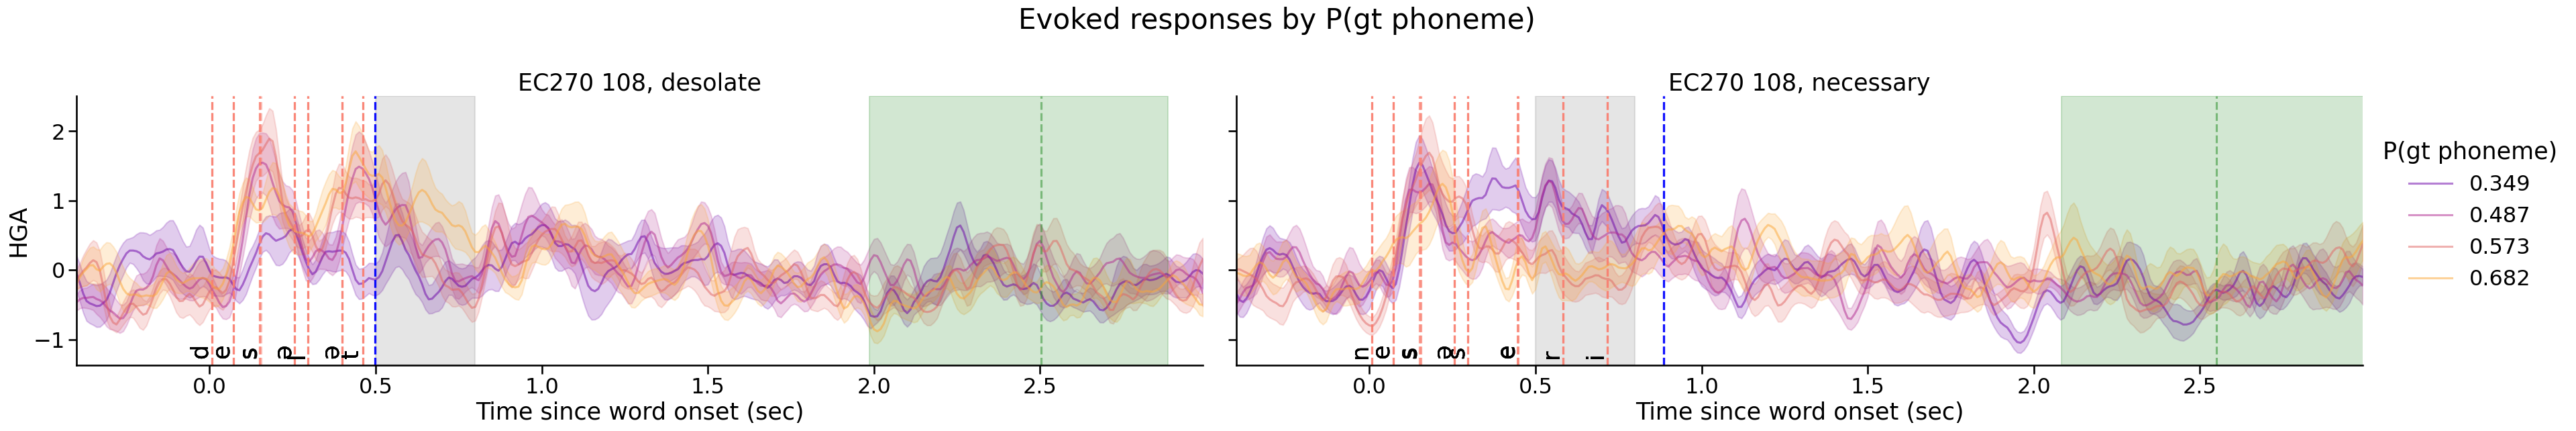

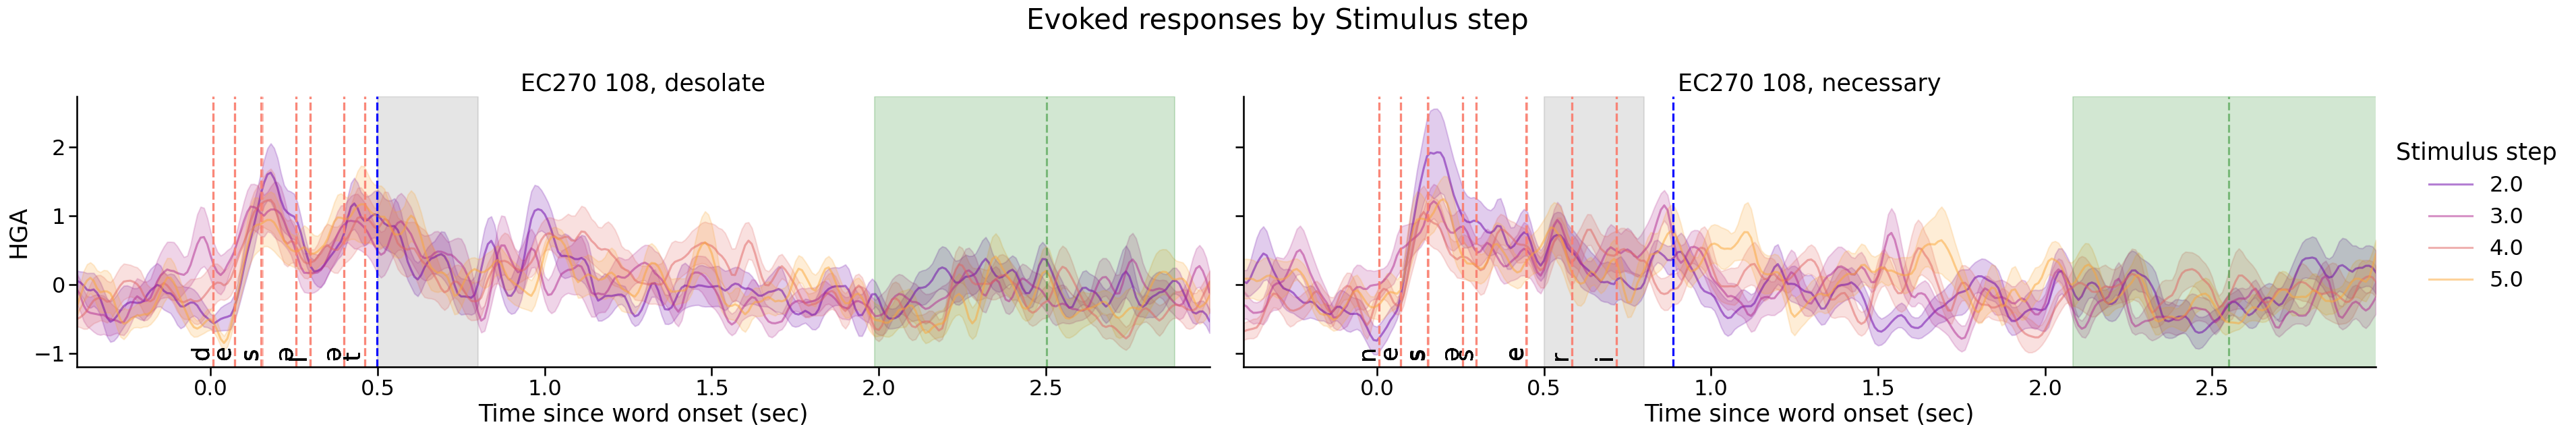

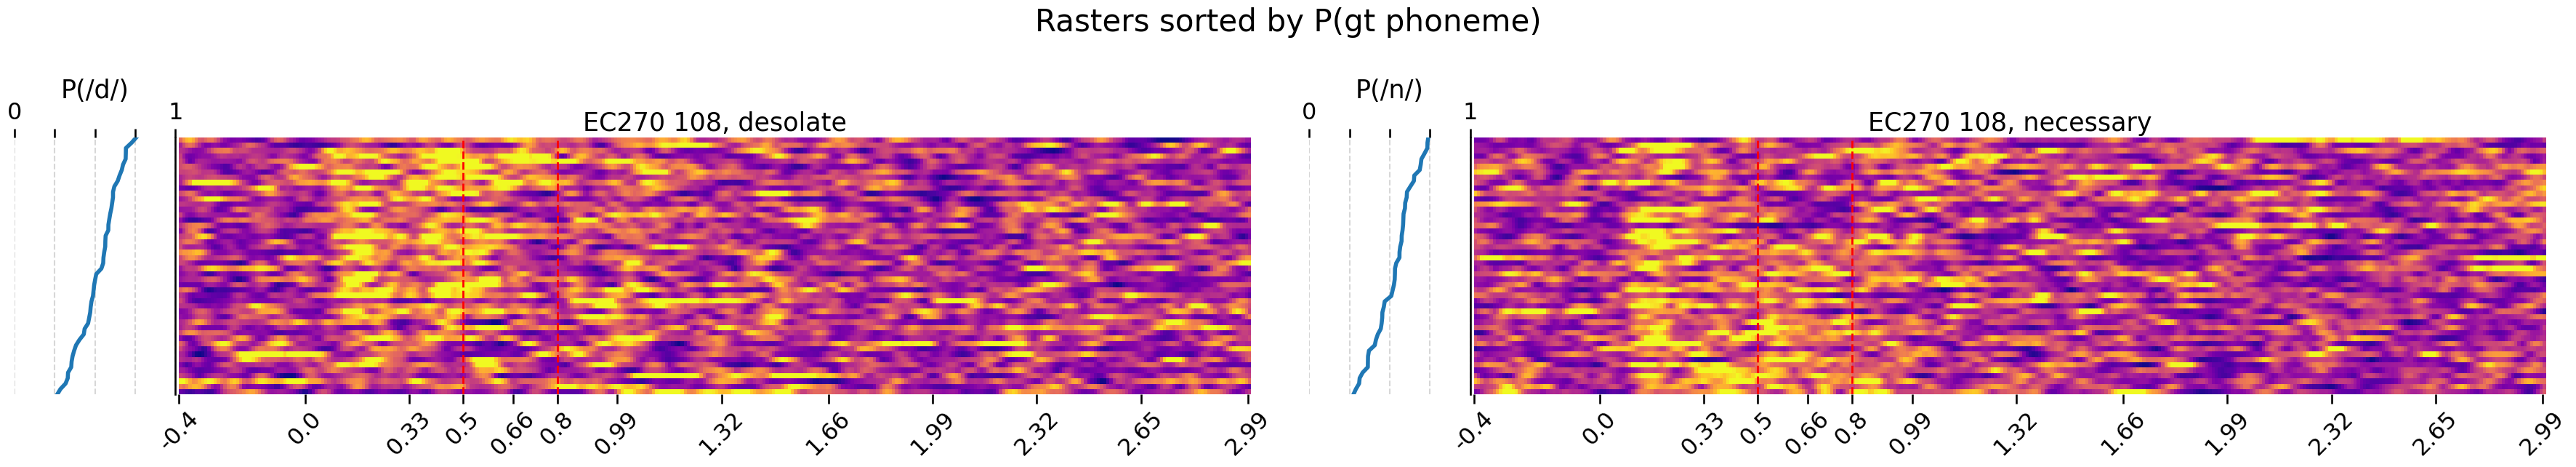

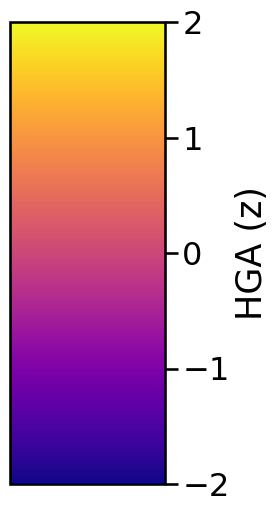

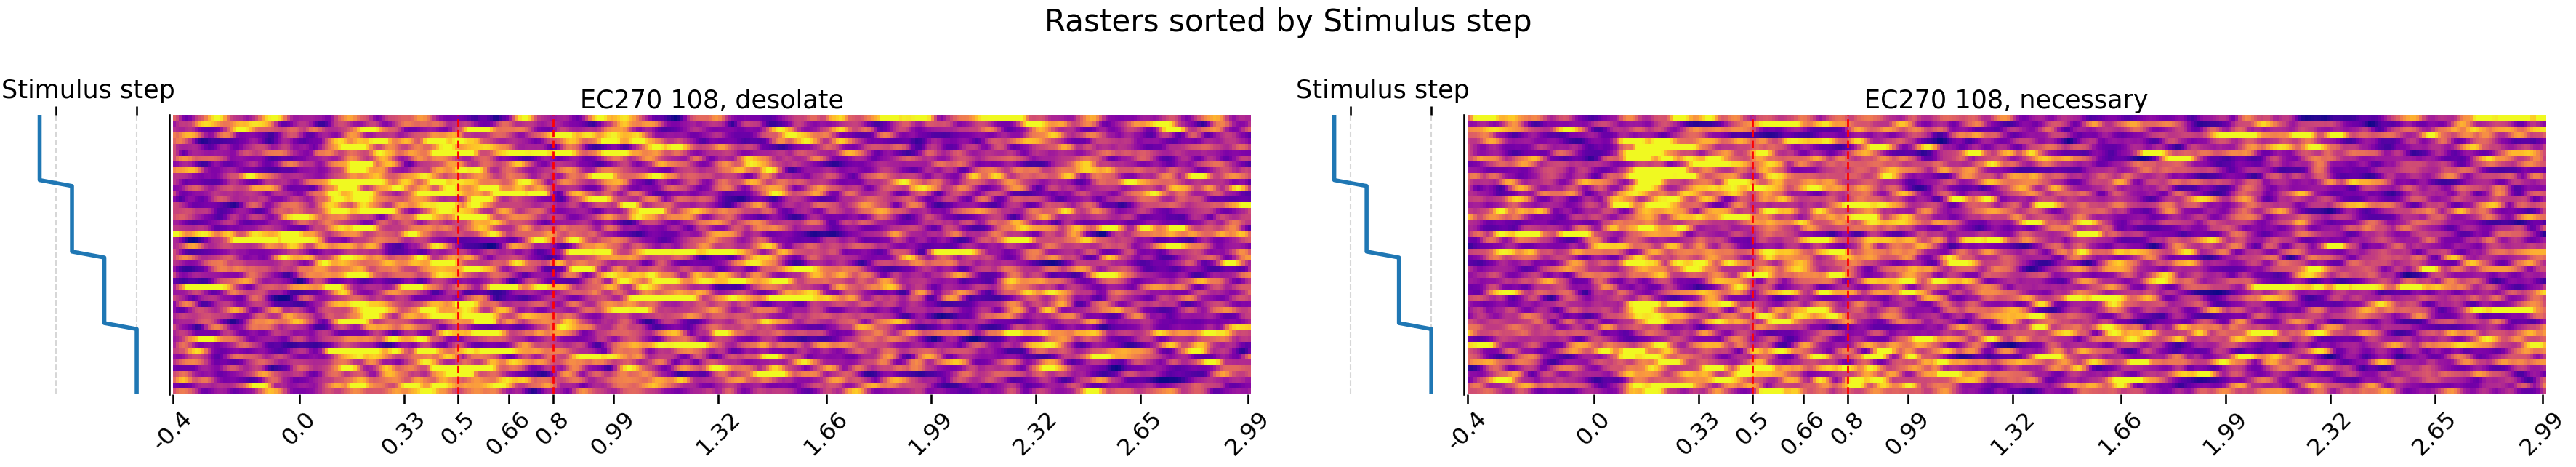

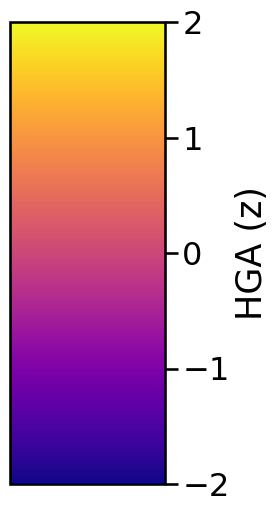

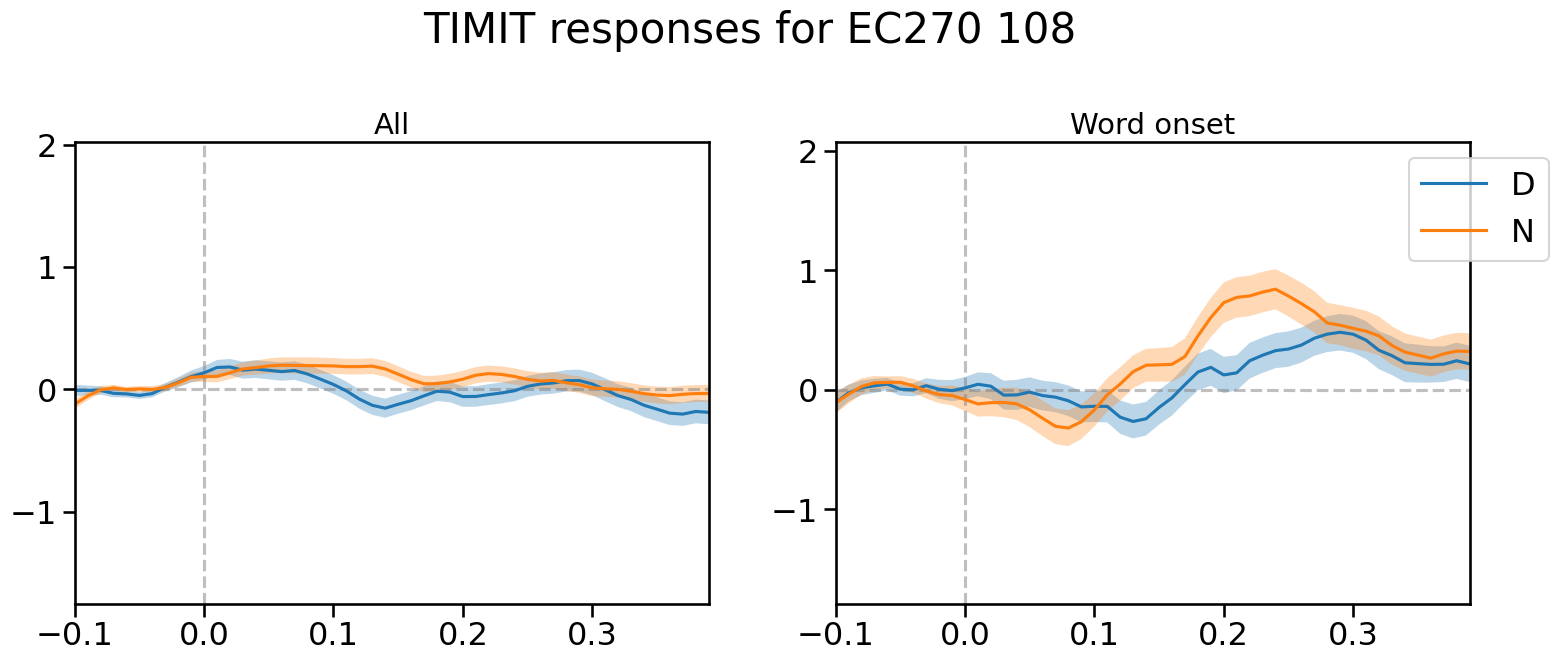

In [53]:
plot_row =  searchlight_results_df.query("subject == 'EC270' and electrode_idx == 107 and phoneme_pair == 'dn'").iloc[0]
print(plot_row)
plot_searchlight_response(plot_row)
None

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages(f"{outdir}/searchlight_results.pdf") as pdf:
    for _, row in tqdm(searchlight_results_df.sort_values("p_val_min").iterrows(), total=len(searchlight_results_df)):
        facetgrids = plot_searchlight_response(row)
        for fg in facetgrids:
            if fg is None:
                continue
            fg.tight_layout()
            fig = fg.fig if hasattr(fg, 'fig') else fg
            pdf.savefig(fig)
            plt.close(fig)